# Football clip analysis with Claude (video first, tracking data second)
1. Extract frames from the clip
2. **Estimate the price** for every model
3. Confirm, then run the analysis

In [1]:
%pip install -q anthropic opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os, math, base64, getpass
import cv2
import anthropic
from IPython.display import display, Image, Markdown

# ---------- CONFIG ----------
CLIP_PATH = r"C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\clips_buildup\lost_under_pressure\b041_BAR_12-01.mp4"  # path to the clip to analyze
TRACKING_PATH = r"C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\prompts\lost_under_pressure\b041_BAR_12-01.txt"          # None -> looks for <clip name>.txt next to the clip       # None -> looks for <clip name>.txt next to the clip
FPS_TO_SEND = 4               # frames per second sent to Claude (try 2, 4, 5)
WIDTH = 960                   # frames are resized to this width
MODEL = "claude-sonnet-5-5"   # model used for the real run
EXPECTED_OUTPUT_TOKENS = 700  # ~350 words (+ margin)
MAX_FRAMES = 100

# USD per million tokens: (input, output). Haiku 5.5 costs more for prompts > 100k tokens.
PRICES = {
    "claude-haiku-5-5":  (0.10, 0.50),
    "claude-sonnet-5-5": (2.0, 10.0),
    "claude-opus-5-5":   (4.0, 20.0),
    "claude-fable-5-1":  (10.0, 50.0),
}
HAIKU_LONG = (0.50, 2.50)

if "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API key: ")
client = anthropic.Anthropic()

Source 25.0 fps | sending every 6 frames -> 61 frames of 960x540


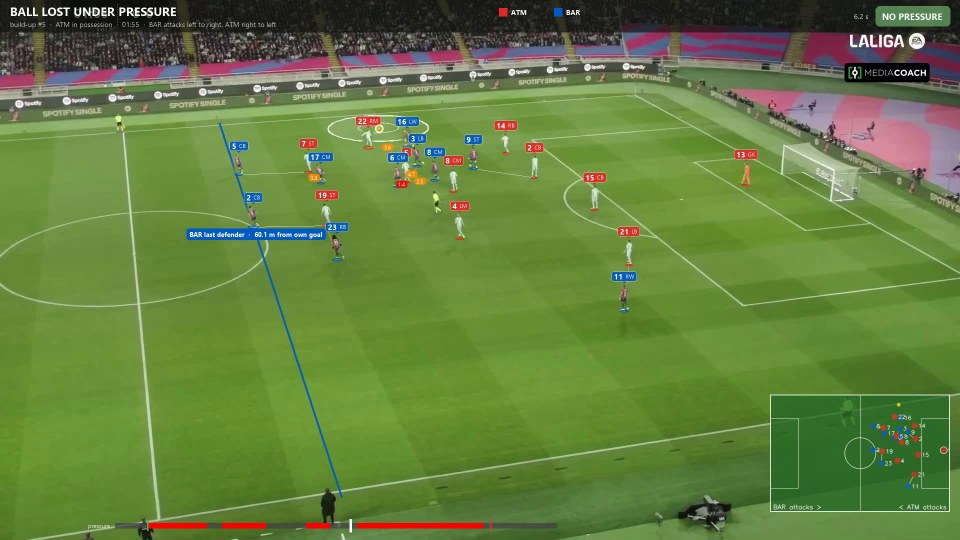

In [47]:
def fmt(t):
    return f"{int(t // 60):02d}:{t % 60:04.1f}"

def extract_frames(path, fps, width, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {path}")
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    step = max(1, round(src_fps / fps))
    frames, idx = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % step == 0:
            h, w = frame.shape[:2]
            if w > width:
                frame = cv2.resize(frame, (width, round(h * width / w)))
            ok2, buf = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 88])
            if ok2:
                frames.append({"t": idx / src_fps, "b64": base64.b64encode(buf).decode(),
                               "w": frame.shape[1], "h": frame.shape[0], "jpg": buf.tobytes()})
        idx += 1
    cap.release()
    if len(frames) > max_frames:
        frames = [frames[round(i * (len(frames) - 1) / (max_frames - 1))] for i in range(max_frames)]
    print(f"Source {src_fps:.1f} fps | sending every {step} frames -> {len(frames)} frames "
          f"of {frames[0]['w']}x{frames[0]['h']}")
    return frames

frames = extract_frames(CLIP_PATH, FPS_TO_SEND, WIDTH)
display(Image(data=frames[len(frames)//2]["jpg"]))   # preview of the middle frame

In [48]:
PREFACE = """You are a football tactical analyst. The images above are frames sampled from ONE short clip,
each labelled with its CLIP time (mm:ss.s from the start of the video).

PRIORITY OF EVIDENCE
1. The VIDEO FRAMES are the ground truth. Everything you say about what happens (who has the ball, who
   presses, how the ball is lost, positions, distances you can see) must come from the frames.
2. The TRACKING DATA below is only a supplement: use it for exact numbers (distances, closing speeds,
   number of pressers, timing) and for player names + shirt numbers, but ONLY where it agrees with the
   frames.
3. If any data detail does not match the frames, silently follow the video and leave that data detail out.
   NEVER mention a contradiction, mismatch, tracking error or doubt between the video and the data in
   your answer. Write as if there were none.
4. Never invent numbers. Frames are sampled, so do not claim anything you cannot see in a frame or read
   from the data (cite the clip time for visual claims).

The original task, rules and output format follow."""

tracking_path = TRACKING_PATH or os.path.splitext(CLIP_PATH)[0] + ".txt"
if os.path.exists(tracking_path):
    tracking = open(tracking_path, encoding="utf-8").read()
    print("Tracking data loaded:", tracking_path)
else:
    tracking = ""
    print("No tracking file found -> video-only analysis:", tracking_path)

final_text = PREFACE + ("\n\n" + tracking if tracking else
                        "\n\nNo tracking data is available for this clip: analyse the video only.")

content = []
for f in frames:
    content.append({"type": "text", "text": f"Frame at clip time {fmt(f['t'])}:"})
    content.append({"type": "image", "source": {"type": "base64", "media_type": "image/jpeg", "data": f["b64"]}})
content.append({"type": "text", "text": final_text})
messages = [{"role": "user", "content": content}]

Tracking data loaded: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\prompts\lost_under_pressure\b005_ATM_01-49.txt


In [49]:
# ---------- PRICE ESTIMATE (nothing is sent to the model here) ----------
image_tokens = sum(math.ceil(f["w"] / 28) * math.ceil(f["h"] / 28) for f in frames)
label_tokens = len(frames) * 10
text_tokens  = int(len(final_text) / 3)            # conservative chars-per-token
est_input    = image_tokens + label_tokens + text_tokens

# Optional exact count (free endpoint). Falls back to the estimate if unavailable.
try:
    exact = client.messages.count_tokens(model=MODEL, messages=messages).input_tokens
    print(f"Exact input tokens for {MODEL}: {exact:,} (formula estimate was {est_input:,})")
    est_input = exact
except Exception as e:
    print(f"(count_tokens unavailable, using formula estimate) {type(e).__name__}")

print(f"\nFrames: {len(frames)} | image tokens ~{image_tokens:,} | text tokens ~{text_tokens:,}")
print(f"TOTAL INPUT ~{est_input:,} tokens | OUTPUT assumed {EXPECTED_OUTPUT_TOKENS} tokens\n")

print(f"{'Model':<20}{'Per clip':>12}{'Batch (-50%)':>15}{'x 100 clips':>14}")
for m, (pin, pout) in PRICES.items():
    if m == "claude-haiku-5-5" and est_input > 100_000:
        pin, pout = HAIKU_LONG
    c = est_input * pin / 1e6 + EXPECTED_OUTPUT_TOKENS * pout / 1e6
    mark = "  <- selected" if m == MODEL else ""
    print(f"{m:<20}${c:>10.4f}${c/2:>14.4f}${c*100:>13.2f}{mark}")

Exact input tokens for claude-sonnet-5-5: 47,902 (formula estimate was 46,319)

Frames: 61 | image tokens ~42,700 | text tokens ~3,009
TOTAL INPUT ~47,902 tokens | OUTPUT assumed 700 tokens

Model                   Per clip   Batch (-50%)   x 100 clips
claude-haiku-5-5    $    0.0051$        0.0026$         0.51
claude-sonnet-5-5   $    0.1028$        0.0514$        10.28  <- selected
claude-opus-5-5     $    0.2056$        0.1028$        20.56
claude-fable-5-1    $    0.5140$        0.2570$        51.40


In [50]:
# ---------- CONFIRM, THEN RUN ----------
answer = input(f"Proceed with {MODEL}? (y/n): ").strip().lower()
if answer != "y":
    raise SystemExit("Cancelled - nothing was sent.")

resp = client.messages.create(
    model=MODEL,
    max_tokens=4000,                  # room for thinking + the 350-word answer
    # thinking={"type": "disabled"},  # optional: fixed, cheaper cost
    messages=messages,
)

# keep only the text blocks (skip thinking blocks)
text = "".join(b.text for b in resp.content if b.type == "text")
display(Markdown(text))

pin, pout = PRICES[MODEL]
u = resp.usage
if MODEL == "claude-haiku-5-5" and u.input_tokens > 100_000:
    pin, pout = HAIKU_LONG
cost = u.input_tokens * pin / 1e6 + u.output_tokens * pout / 1e6
print(f"\nWords: {len(text.split())} | tokens in={u.input_tokens:,} out={u.output_tokens:,} | actual cost ${cost:.4f}")

**1. VERDICT**
BAR's pressure worked. ATM's build-up in its own third ended in a turnover at 00:11, when Fermín #16 took the ball from the ATM move. The pressure was light (never more than 2 pressers) but persistent, and it forced ATM into a slow, sideways build-up that BAR was able to break up.

**2. WHY**
1. **Pressure came early and was repeated.** Llorente #14 (RB) was pressed at 00:00–00:02 by Pedri #8 (1.3 m, 3.4 m/s closing), with Simeone #22 and Lewandowski #9 also closing in. In the frames at 00:01.2–00:01.9 ATM's RB is surrounded by BAR players. The ball goes back from 72.8 m to 25.2 m. Further episodes at 00:03–00:04 (Balde #3, 0.9 m) and 00:05–00:06 (Pedri again, 1.2 m) kept ATM from ever getting settled.

2. **ATM circulated in a tight pocket and never progressed.** From 00:01 to 00:08 the ball stayed at 24–33 m from ATM's goal, passing among Llorente #14, Barrios #8 and De Paul #5. At 00:03.4–00:06.0 BAR's 3, 5, 6, 8 and 17 are packed around the ball near the centre circle. ATM had free options at the start (7 free, 5 ahead at 00:01, including Gimenez #2 7 m away and De Paul #5 13 m away) but did not use them, so BAR could shift across.

3. **The final press was close and the carrier was isolated.** After the ball went wide to Simeone #22 at 00:08, it reached Fermín #16 at the touchline, y=66.9. Fermín #16 was pressing from 0.0 m (3.8 s, 4.7 m/s closing), and Balde #3 (1.8 m) and Inigo #5 arrived in the last second. At 00:10 only 1 free option was ahead of the ball (Alvarez #19, 28 m away). The nearest ATM options were behind or level with the ball.

4. **The turnover came at the touchline.** At 00:11 Griezmann #7 was under pressure at x=41.3 and the ball ended with Fermín #16 at 00:11.3–00:11.5. Four BAR players (22/5/16/3 labels) sit within a few metres in the frame at 00:11.5. ATM's compact block (28.8 m × 49.2 m) was stretched toward the touchline, which left the carrier with little support.

**3. COUNTERFACTUAL**
At 00:01 Llorente #14 had Gimenez #2 (7 m, nearest opponent 4.5 m) and De Paul #5 (13 m, 8.7 m from nearest opponent) free ahead of him. A quick pass to either, or switching play to the far side, would have beaten the first press before BAR's 5–6 players could pack around the ball. Instead ATM stayed in its own third for around 7 s and was forced onto the touchline, where there were no free forward options.


Words: 438 | tokens in=47,902 out=1,038 | actual cost $0.1062
